In [2]:
"""
SarcasmLens – Calibrated Model Trainer (Subtask 2.5)
------------------------------------------------------
Goal:
Train and save a calibrated version of the best-performing model
(LinearSVM) to enable probability-based confidence scores.

This script modifies the original training pipeline to wrap the
LinearSVC model in a `CalibratedClassifierCV`.
"""

# =======================================================
# 1. Imports
# =======================================================
import pandas as pd
import numpy as np
import re
import joblib
import json
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV  # <-- IMPORTCALIBRATOR

# =======================================================
# 2. Load Dataset
# =======================================================
# --- Make sure this path is correct ---
path = r"D:\DAIICT\Sem 3\NLP\Project\SarcasmLens---Subjective-Sarcasm-Detection-in-Code-Mixed-Text.-main\Dataset\unique_tweets.csv"
df = pd.read_csv(path)
print("\n===== Dataset Information =====")
print(f"Dataset shape: {df.shape}\n")

# Automatically detect text and label columns
possible_text_cols = [col for col in df.columns if "tweet" in col.lower() or "text" in col.lower()]
possible_label_cols = [col for col in df.columns if "label" in col.lower()]
text_col = possible_text_cols[0] if possible_text_cols else df.columns[1]
label_col = possible_label_cols[0] if possible_label_cols else df.columns[-1]

df = df[[text_col, label_col]]
df.columns = ["text", "label"]

# =======================================================
# 3. Text Cleaning
# =======================================================
def clean_text(text):
    """
    Cleans text by removing URLs, mentions, hashtags, and unwanted symbols.
    Retains Hindi + English characters and punctuation (!, ?), as these may carry
    sarcastic intent.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # Remove URLs
    text = re.sub(r"@[A-Za-z0-9_]+", "", text)       # Remove mentions
    text = re.sub(r"#", "", text)                    # Remove hashtags
    text = re.sub(r"[^a-zA-Z\u0900-\u097F!?'\s]", " ", text)  # Keep Hindi & English
    text = re.sub(r"\s+", " ", text).strip()         # Normalize spaces
    return text

df["text"] = df["text"].apply(clean_text)
print("Text cleaning completed.")

# =======================================================
# 4. Train/Test Split
# =======================================================
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}\n")

# =======================================================
# 5. Define TF-IDF Vectorizer
# =======================================================
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    sublinear_tf=True,
)

# =======================================================
# 6. Define Calibrated Model
# =======================================================
print("Defining Calibrated LinearSVM model...")
# First, define the base model (your best model)
base_svm = LinearSVC(C=1.0, random_state=42, dual="auto") # Added dual="auto" to suppress warning

# Next, wrap it in the calibrator.
# method='isotonic' is often better but requires more data.
# method='sigmoid' (Platt scaling) is also a good choice.
# cv=5 means it will use 5-fold cross-validation *on the training data*
# to build the calibration model.
calibrated_model = CalibratedClassifierCV(
    base_svm,
    method='isotonic',  # Use 'isotonic' or 'sigmoid'
    cv=5
)

model_name = "CalibratedLinearSVM"

# =======================================================
# 7. Training and Evaluation
# =======================================================
print(f"\n==============================\nTraining {model_name}\n==============================")
# Create the pipeline
clf = Pipeline([
    ("tfidf", tfidf),
    ("model", calibrated_model)  # Use the calibrated model
])

# Fit the pipeline
# This will first train the base_svm on folds, then train the calibrator
clf.fit(X_train, y_train)
print("Model training complete.")

# Evaluate on the test set
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy: {acc:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# =======================================================
# 8. Save the Calibrated Model
# =======================================================
output_model_path = "calibrated_sarcasm_model.pkl"
joblib.dump(clf, output_model_path)

print(f"\n========================================")
print(f"Successfully trained and saved calibrated model to:")
print(f"{output_model_path}")
print("========================================\n")


===== Dataset Information =====
Dataset shape: (11367, 3)

Text cleaning completed.
Training samples: 9093, Testing samples: 2274

Defining Calibrated LinearSVM model...

Training CalibratedLinearSVM
Model training complete.
Accuracy: 0.9714
Weighted F1-Score: 0.9714

Classification Report:
               precision    recall  f1-score   support

          NO     0.9674    0.9644    0.9659       954
         YES     0.9743    0.9765    0.9754      1320

    accuracy                         0.9714      2274
   macro avg     0.9709    0.9704    0.9706      2274
weighted avg     0.9714    0.9714    0.9714      2274

Confusion Matrix:
 [[ 920   34]
 [  31 1289]]

Successfully trained and saved calibrated model to:
calibrated_sarcasm_model.pkl



Graphs will be saved to: d:\DAIICT\Sem 3\NLP\Project\SarcasmLens---Subjective-Sarcasm-Detection-in-Code-Mixed-Text.-main\Baseline system\graphs

--- Part 1: Prediction ---
Loading calibrated model from calibrated_sarcasm_model.pkl...
Model loaded successfully.
Loading data from D:\DAIICT\Sem 3\NLP\Project\SarcasmLens---Subjective-Sarcasm-Detection-in-Code-Mixed-Text.-main\Dataset\unique_tweets.csv...
Cleaning test data...
Generating predictions and confidence scores...
Prediction complete.

Successfully saved predictions with confidence scores to:
test_predictions_with_confidence.csv

Sample of saved results:
        ID                                              Tweet Label  \
0   7640.0  takeout burrito shielded from cold as though i...   YES   
1  11848.0  sight of coworkers' stupid fucking faces endur...   YES   
2  13098.0                                porch ceded to bats   YES   
3   7530.0  panicked donald trump jr. tries to cover up co...   YES   
4   7973.0  mike gravel can'

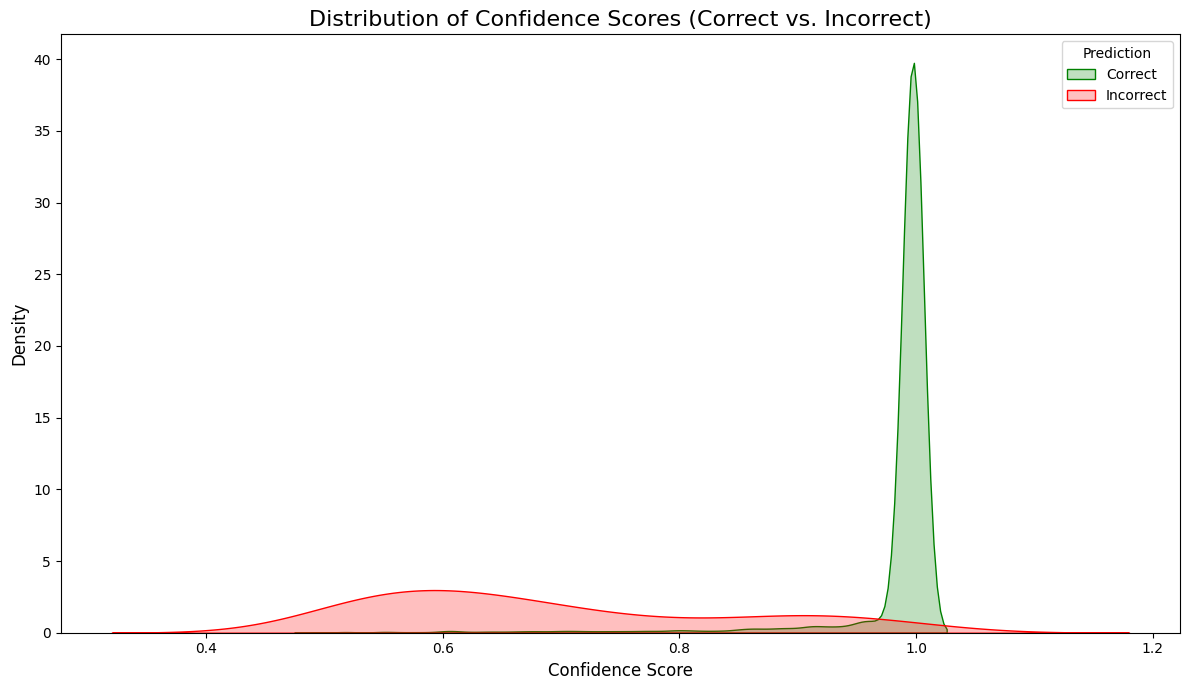


Generating calibration plot (Reliability Diagram)...
Saved: d:\DAIICT\Sem 3\NLP\Project\SarcasmLens---Subjective-Sarcasm-Detection-in-Code-Mixed-Text.-main\Baseline system\graphs\calibration_plot.png


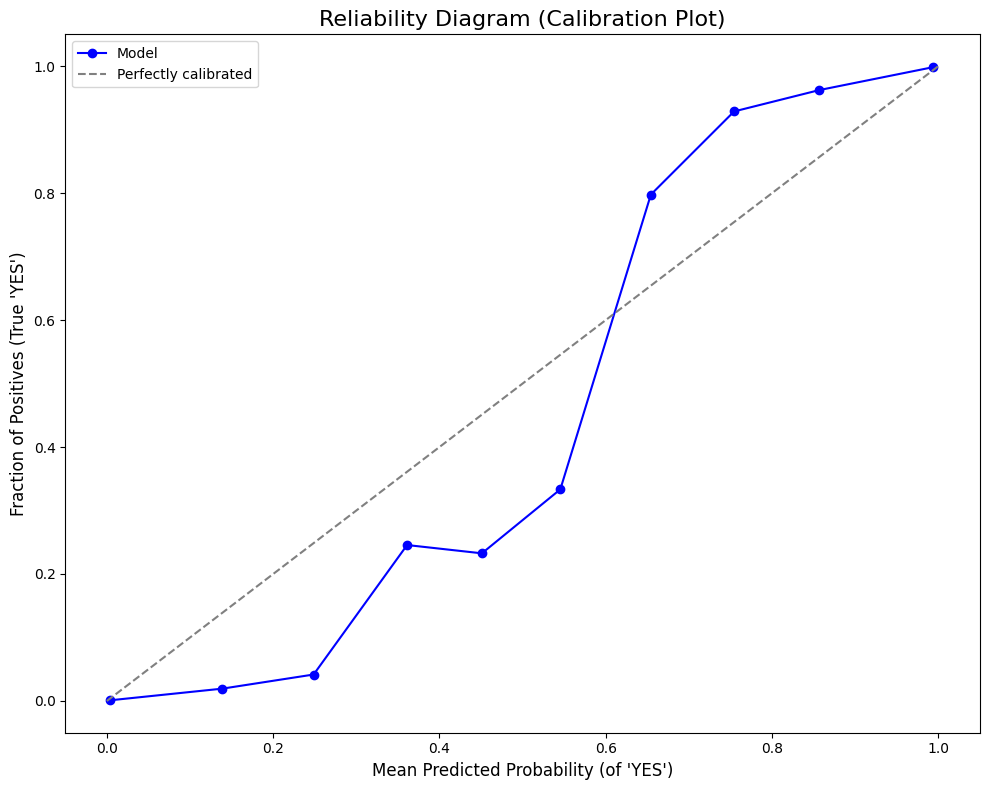

In [3]:
"""
SarcasmLens – Predict, Analyze, and Report
-------------------------------------------------
Goal:
A single script that loads the calibrated model, runs predictions
on a test set, saves the results, and then immediately
analyzes the model's confidence and errors.

This script combines 'predict_with_confidence.py' and 'analyze_confidence.py'.

Part 1: Prediction
- Loads 'calibrated_sarcasm_model.pkl'.
- Loads 'unique_tweets.csv' as the test set (since it has true labels).
- Cleans the text.
- Predicts labels, confidence scores, and 'probability_YES'.
- Saves results to 'test_predictions_with_confidence.csv'.

Part 2: Analysis
- Uses the prediction results (in memory).
- Prints avg. confidence for correct/incorrect predictions.
- Prints the most "confidently wrong" examples.
- Saves 'confidence_distribution_kde.png'.
- Saves 'calibration_plot.png'.
"""

# =======================================================
# 1. Imports
# =======================================================
import pandas as pd
import numpy as np
import re
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.calibration import calibration_curve  # For manual calibration curve

# =======================================================
# 2. Define Paths
# =======================================================
# --- Make sure these paths are correct ---
MODEL_PATH = "calibrated_sarcasm_model.pkl"
DATA_PATH = r"D:\DAIICT\Sem 3\NLP\Project\SarcasmLens---Subjective-Sarcasm-Detection-in-Code-Mixed-Text.-main\Dataset\unique_tweets.csv" 
OUTPUT_CSV_PATH = "test_predictions_with_confidence.csv"

# --- Outputs will be saved here ---
CURRENT_DIRECTORY = os.getcwd()
GRAPH_PATH = os.path.join(CURRENT_DIRECTORY, "graphs")
os.makedirs(GRAPH_PATH, exist_ok=True)
print(f"Graphs will be saved to: {GRAPH_PATH}")

# =======================================================
# 3. Text Cleaning Function (MUST be identical to training)
# =======================================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # Remove URLs
    text = re.sub(r"@[A-Za-z0-9_]+", "", text)       # Remove mentions
    text = re.sub(r"#", "", text)                    # Remove hashtags
    text = re.sub(r"[^a-zA-Z\u0900-\u097F!?'\s]", " ", text)  # Keep Hindi & English
    text = re.sub(r"\s+", " ", text).strip()         # Normalize spaces
    return text

# =======================================================
# 4. Part 1: Load Model and Data
# =======================================================
print(f"\n--- Part 1: Prediction ---")
print(f"Loading calibrated model from {MODEL_PATH}...")
try:
    clf = joblib.load(MODEL_PATH)
except FileNotFoundError:
    print(f"Error: Model file not found at {MODEL_PATH}")
    print("Please run 'train_calibrated_model.py' first.")
    exit()
print("Model loaded successfully.")

print(f"Loading data from {DATA_PATH}...")
try:
    df_test = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print(f"Error: Test file not found at {DATA_PATH}")
    exit()

# Detect text column
possible_text_cols = [col for col in df_test.columns if "tweet" in col.lower() or "text" in col.lower()]
text_col = possible_text_cols[0] if possible_text_cols else df_test.columns[1]
# Keep the 'Label' column for analysis
df_test_processed = df_test[[text_col, 'Label']].copy()
df_test_processed.columns = ["text", "Label"]

# =======================================================
# 5. Part 1: Preprocessing and Prediction
# =======================================================
print("Cleaning test data...")
df_test_processed["cleaned_text"] = df_test_processed["text"].apply(clean_text)

print("Generating predictions and confidence scores...")
X_to_predict = df_test_processed["cleaned_text"]

# Get predicted labels
predicted_labels = clf.predict(X_to_predict)

# Get prediction probabilities
all_probabilities = clf.predict_proba(X_to_predict)

# The confidence score is the *highest* probability
confidence_scores = np.max(all_probabilities, axis=1)

# Get probability of the 'YES' class
class_labels = clf.classes_
yes_index = np.where(class_labels == 'YES')[0][0]
probability_yes = all_probabilities[:, yes_index]

print("Prediction complete.")

# =======================================================
# 6. Part 1: Save Results
# =======================================================
# Create a new DataFrame with all the results
df_results = df_test.copy()
df_results["predicted_label"] = predicted_labels
df_results["confidence_score"] = confidence_scores
df_results["probability_YES"] = probability_yes # Add the new column

# Save to CSV
df_results.to_csv(OUTPUT_CSV_PATH, index=False, encoding="utf-8")

print(f"\n========================================")
print(f"Successfully saved predictions with confidence scores to:")
print(f"{OUTPUT_CSV_PATH}")
print("========================================\n")
print("Sample of saved results:")
print(df_results.head())

# =======================================================
# 7. Part 2: Prepare Data for Analysis
# =======================================================
print(f"\n--- Part 2: Analysis ---")
# No need to load CSV, we can use df_results directly
print("Starting analysis on prediction results...")
df = df_results.copy() # Use the results from memory

df['is_correct'] = (df['Label'] == df['predicted_label'])
# Map YES/NO to 1/0 for calibration plot
df['true_label_int'] = df['Label'].map({'YES': 1, 'NO': 0})
print("Analysis data prepared.")

# =======================================================
# 8. Part 2: Print Confidence Statistics
# =======================================================
accuracy = accuracy_score(df['Label'], df['predicted_label'])
avg_confidence_correct = df[df['is_correct'] == True]['confidence_score'].mean()
avg_confidence_incorrect = df[df['is_correct'] == False]['confidence_score'].mean()

print("\n===== Confidence Statistics =====")
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Average Confidence (Correct):   {avg_confidence_correct:.4f}")
print(f"Average Confidence (Incorrect): {avg_confidence_incorrect:.4f}")

# =======================================================
# 9. Part 2: Analyze and Print "Confidently Wrong" Errors
# =======================================================
CONFIDENCE_THRESHOLD = 0.90  # Look for errors with > 90% confidence

confident_errors = df[(
    df['is_correct'] == False) & 
    (df['confidence_score'] > CONFIDENCE_THRESHOLD)
]

print(f"\nFound {len(confident_errors)} errors with > {CONFIDENCE_THRESHOLD*100}% confidence.")
print("-------------------------------------------------")
print("Top 10 Most Confidently Wrong Predictions:")
print("-------------------------------------------------")

# Sort by confidence and show the top 10
for _, row in confident_errors.sort_values(by='confidence_score', ascending=False).head(10).iterrows():
    print(f"\nCONFIDENCE: {row['confidence_score']:.3f}")
    print(f"  PREDICTED: {row['predicted_label']}")
    print(f"  ACTUAL:    {row['Label']}")
    print(f"  TWEET:     {row['Tweet']}")

# =======================================================
# 10. Part 2: Plot 1: Confidence Distribution (KDE Plot)
# =======================================================
print("\nGenerating confidence distribution plot (kde)...")
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='confidence_score', hue='is_correct', 
            fill=True, common_norm=False, palette={True: "green", False: "red"})
plt.title("Distribution of Confidence Scores (Correct vs. Incorrect)", fontsize=16)
plt.xlabel("Confidence Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(title='Prediction', labels=['Correct', 'Incorrect'])
plt.tight_layout()
plot_path_kde = os.path.join(GRAPH_PATH, "confidence_distribution_kde.png")
plt.savefig(plot_path_kde)
print(f"Saved: {plot_path_kde}")
plt.show()

# =======================================================
# 11. Part 2: Plot 2: Reliability Diagram (Calibration Plot)
# =======================================================
print("\nGenerating calibration plot (Reliability Diagram)...")

# Generate calibration curve data
prob_true, prob_pred = calibration_curve(df['true_label_int'], df['probability_YES'], n_bins=10)

# Plot the calibration curve manually
plt.figure(figsize=(10, 8))
plt.plot(prob_pred, prob_true, marker='o', label="Model", color='blue')
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated", color='gray')
plt.title("Reliability Diagram (Calibration Plot)", fontsize=16)
plt.xlabel("Mean Predicted Probability (of 'YES')", fontsize=12)
plt.ylabel("Fraction of Positives (True 'YES')", fontsize=12)
plt.legend()
plt.tight_layout()
plot_path_cal = os.path.join(GRAPH_PATH, "calibration_plot.png")
plt.savefig(plot_path_cal)
print(f"Saved: {plot_path_cal}")
plt.show()

